# 08 - STL decomposition PLR

This notebook estimates module-level performance loss rates using seasonal-trend decomposition with Loess (STL).

STL is applied to monthly \(PR_\mathrm{DC,25C}\) time series. Each module series is first regularised to a complete monthly index. Internal missing monthly values are linearly interpolated only for the purpose of decomposition and are flagged in the output.

The central PLR estimate is calculated from the STL trend component. Uncertainty is estimated using the trend-plus-residual series, so that residual variability is reflected in the confidence interval.

The main outputs are:

1. STL PLR estimates for the main g200 dataset
2. STL decomposition outputs for each module
3. a module-level STL PLR summary figure
4. an all-module STL trend-fit figure
5. selected STL decomposition diagnostic figures
6. ensemble-ready STL results

## 1. Imports and plotting style

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from statsmodels.tsa.seasonal import STL
from scipy import stats
from matplotlib.lines import Line2D
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 11,
    "legend.title_fontsize": 11,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 11

## 2. Paths

In [3]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
PLR_INPUT_DIR = DATA_PROCESSED_DIR / "plr_final_inputs"
STL_OUTPUT_DIR = DATA_PROCESSED_DIR / "stl_outputs"

FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "final figures"
FINAL_TABLE_DIR = PROJECT_ROOT / "tables" / "final tables"

for folder in [STL_OUTPUT_DIR, FINAL_FIG_DIR, FINAL_TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MONTHLY_INPUT_PATHS = {
    "g200": PLR_INPUT_DIR / "g200_monthly_pr25c_filtered_for_plr.parquet",
    "g400": PLR_INPUT_DIR / "g400_monthly_pr25c_filtered_for_plr.parquet",
}

DATASET_LABELS = {
    "g200": r"$G_\mathrm{POA} \geq 200$ W/m$^2$",
    "g400": r"$G_\mathrm{POA} \geq 400$ W/m$^2$",
}

MAIN_DATASET = "g200"
SENSITIVITY_DATASET = "g400"

print("Project root:", PROJECT_ROOT)
print("PLR input folder:", PLR_INPUT_DIR)
print("STL output folder:", STL_OUTPUT_DIR)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    print(f"{dataset_name} input exists:", path.exists(), "|", path)

Project root: C:\Users\amina\Thesis\Final Pipeline
PLR input folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs
STL output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\stl_outputs
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
g200 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g200_monthly_pr25c_filtered_for_plr.parquet
g400 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g400_monthly_pr25c_filtered_for_plr.parquet


## 3. Constants and module metadata

The STL input metric is monthly \(PR_\mathrm{DC,25C}\). The STL period is set to 12 months to represent the annual seasonal cycle.

In [4]:
MAIN_METRIC = "PR_25C"
TIME_COL = "Month_Start"

MIN_MONTHS_FOR_STL = 24

STL_PERIOD = 12
STL_SEASONAL = 13
STL_TREND = 31
STL_ROBUST = True

DAYS_PER_YEAR = 365.25
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL

BLACK = "#222222"
GREY = "#BDBDBD"

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
    "Unknown": "#666666",
}

module_meta = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))

display(module_meta)

,Module_ID,Type
0,1,PID/Reference
1,2,Reference
2,3,uCrack
3,4,uCrack
4,5,Reference
5,6,uCrack
6,7,uCrack
7,8,uCrack
8,9,uCrack
9,10,Reference


## 4. Helper functions

In [5]:
def save_fig(filename, fig=None):
    """
    Save figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def format_year_axis(ax):
    """
    Format x-axis with annual ticks.
    """
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)


def strip_timezone(series):
    """
    Convert a datetime series to timezone-naive timestamps.
    """
    series = pd.to_datetime(series)

    if getattr(series.dt, "tz", None) is not None:
        return series.dt.tz_convert(None)

    return series


def normalise_type_label(value):
    """
    Normalise module category labels across input files.
    """
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLORS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


def module_category_legend_handles():
    """
    Legend handles for module categories.
    """
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="uCrack",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
    ]

## 5. Load monthly PLR input datasets

The STL method is applied to monthly \(PR_\mathrm{DC,25C}\). The g200 dataset is used as the main STL input, while g400 is retained as an irradiance-threshold sensitivity dataset.

In [6]:
monthly_datasets = {}

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing monthly input for {dataset_name}: {path}")

    df = pd.read_parquet(path)

    if "Month_Start" in df.columns:
        df["Month_Start"] = strip_timezone(df["Month_Start"])
    elif "YearMonth" in df.columns:
        df["Month_Start"] = pd.to_datetime(df["YearMonth"].astype(str))
    else:
        raise ValueError(f"{dataset_name}: missing Month_Start or YearMonth column.")

    if "YearMonth" not in df.columns:
        df["YearMonth"] = df["Month_Start"].dt.to_period("M").astype(str)

    if "Type" not in df.columns:
        df = df.merge(module_meta, on="Module_ID", how="left")

    df["Type"] = df["Type"].apply(normalise_type_label)
    df["dataset"] = dataset_name
    df["dataset_label"] = DATASET_LABELS[dataset_name]
    df["module_color"] = df["Type"].map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"])

    df = df.sort_values(["Module_ID", "Month_Start"]).reset_index(drop=True)

    required_cols = ["Module_ID", "Type", "Month_Start", "YearMonth", MAIN_METRIC]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"{dataset_name}: missing required columns: {missing_cols}")

    duplicate_count = df.duplicated(subset=["Module_ID", "Month_Start"]).sum()
    if duplicate_count > 0:
        raise ValueError(f"{dataset_name}: duplicate Module_ID-Month_Start rows found.")

    monthly_datasets[dataset_name] = df

    print(f"{dataset_name} loaded")
    print("Shape:", df.shape)
    print("Month range:", df["Month_Start"].min(), "to", df["Month_Start"].max())
    print("Modules:", sorted(df["Module_ID"].unique()))
    print("-" * 80)

g200 loaded
Shape: (416, 37)
Month range: 2017-01-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
g400 loaded
Shape: (356, 37)
Month range: 2017-04-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------


## 6. Input summary

This summary records the number of monthly records available in each input dataset.

In [7]:
monthly_input_summary = []

for dataset_name, df in monthly_datasets.items():
    monthly_input_summary.append({
        "Dataset": dataset_name,
        "Input definition": DATASET_LABELS[dataset_name],
        "Monthly records": len(df),
        "Modules": df["Module_ID"].nunique(),
        "First month": df["Month_Start"].min(),
        "Last month": df["Month_Start"].max(),
        "Median PR_DC,25C": df[MAIN_METRIC].median(),
        "Minimum PR_DC,25C": df[MAIN_METRIC].min(),
        "Maximum PR_DC,25C": df[MAIN_METRIC].max(),
    })

monthly_input_summary = pd.DataFrame(monthly_input_summary)

display(monthly_input_summary)

MONTHLY_INPUT_SUMMARY_PATH = FINAL_TABLE_DIR / "stl_monthly_input_summary.csv"

monthly_input_summary.to_csv(
    MONTHLY_INPUT_SUMMARY_PATH,
    index=False,
)

print("Saved monthly input summary:", MONTHLY_INPUT_SUMMARY_PATH)

,Dataset,Input definition,Monthly records,Modules,First month,Last month,"Median PR_DC,25C","Minimum PR_DC,25C","Maximum PR_DC,25C"
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,416,10,2017-01-01,2021-10-01,0.945307,0.650984,1.003170
1,g400,$G_\mathrm{POA} \geq 400$ W/m$^2$,356,10,2017-04-01,2021-10-01,0.950341,0.652970,1.013898


Saved monthly input summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_monthly_input_summary.csv


## 7. Regularise monthly series for STL

STL requires a regular time series. Each module is therefore reindexed to a complete monthly sequence between its first and last available month.

Internal missing \(PR_\mathrm{DC,25C}\) values are linearly interpolated for decomposition only. These months are flagged as imputed and retained in the decomposition output.

In [8]:
def regularise_monthly_series(module_df):
    """
    Convert one module's monthly series to a complete monthly index.

    Internal missing PR_DC,25C values are linearly interpolated for STL.
    Interpolated months are flagged.
    """
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    dataset_name = module_df["dataset"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]
    module_color = module_df["module_color"].iloc[0]

    month_index = pd.date_range(
        start=module_df["Month_Start"].min(),
        end=module_df["Month_Start"].max(),
        freq="MS",
    )

    regular = (
        module_df
        .set_index("Month_Start")
        .reindex(month_index)
        .rename_axis("Month_Start")
        .reset_index()
    )

    regular["Module_ID"] = module_id
    regular["Type"] = module_type
    regular["dataset"] = dataset_name
    regular["dataset_label"] = dataset_label
    regular["module_color"] = module_color
    regular["YearMonth"] = regular["Month_Start"].dt.to_period("M").astype(str)

    regular["PR_25C_observed"] = regular[MAIN_METRIC]
    regular["observed_month"] = regular["PR_25C_observed"].notna()

    regular["PR_25C_stl"] = (
        regular
        .set_index("Month_Start")["PR_25C_observed"]
        .interpolate(method="time", limit_area="inside")
        .values
    )

    regular["imputed_for_stl"] = (
        regular["PR_25C_observed"].isna()
        & regular["PR_25C_stl"].notna()
    )

    regular["module_start_month"] = regular["Month_Start"].min()
    regular["time_days"] = (
        regular["Month_Start"] - regular["module_start_month"]
    ).dt.days
    regular["time_years"] = regular["time_days"] / DAYS_PER_YEAR

    return regular

In [9]:
stl_regular_datasets = {}

for dataset_name, df in monthly_datasets.items():
    regularised_modules = []

    for module_id, module_df in df.groupby("Module_ID"):
        regularised_modules.append(regularise_monthly_series(module_df))

    regular_df = (
        pd.concat(regularised_modules, ignore_index=True)
        .sort_values(["Module_ID", "Month_Start"])
        .reset_index(drop=True)
    )

    stl_regular_datasets[dataset_name] = regular_df

    print(f"{dataset_name} regularised")
    print("Shape:", regular_df.shape)
    print("Observed months:", int(regular_df["observed_month"].sum()))
    print("Imputed months:", int(regular_df["imputed_for_stl"].sum()))
    print("-" * 80)

g200 regularised
Shape: (578, 44)
Observed months: 416
Imputed months: 162
--------------------------------------------------------------------------------
g400 regularised
Shape: (545, 44)
Observed months: 356
Imputed months: 189
--------------------------------------------------------------------------------


## 8. Regularisation summary

This table records observed and interpolated monthly support for each module before STL fitting.

In [10]:
regular_summary_tables = []

for dataset_name, regular_df in stl_regular_datasets.items():
    summary = (
        regular_df
        .groupby(["Module_ID", "Type"], as_index=False)
        .agg(
            n_months_regular=("PR_25C_stl", "size"),
            n_months_observed=("observed_month", "sum"),
            n_months_imputed=("imputed_for_stl", "sum"),
            n_missing_after_interpolation=("PR_25C_stl", lambda x: x.isna().sum()),
            first_month=("Month_Start", "min"),
            last_month=("Month_Start", "max"),
        )
    )

    summary["pct_months_imputed"] = (
        100 * summary["n_months_imputed"] / summary["n_months_regular"]
    )

    summary["eligible_for_stl"] = (
        (summary["n_months_observed"] >= MIN_MONTHS_FOR_STL)
        & (summary["n_missing_after_interpolation"] == 0)
    )

    summary.insert(0, "dataset", dataset_name)
    regular_summary_tables.append(summary)

stl_regularisation_summary = pd.concat(regular_summary_tables, ignore_index=True)

display(stl_regularisation_summary)

STL_REGULARISATION_SUMMARY_PATH = FINAL_TABLE_DIR / "stl_regularisation_summary.csv"

stl_regularisation_summary.to_csv(
    STL_REGULARISATION_SUMMARY_PATH,
    index=False,
)

print("Saved regularisation summary:", STL_REGULARISATION_SUMMARY_PATH)

if not stl_regularisation_summary["eligible_for_stl"].all():
    display(stl_regularisation_summary.loc[~stl_regularisation_summary["eligible_for_stl"]])
    raise ValueError("At least one module-dataset combination is not eligible for STL.")

,dataset,Module_ID,Type,n_months_regular,n_months_observed,n_months_imputed,n_missing_after_interpolation,first_month,last_month,pct_months_imputed,eligible_for_stl
0,g200,1,PID/Reference,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
1,g200,2,Reference,58,43,15,0,2017-01-01,2021-10-01,25.862069,True
2,g200,3,uCrack,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
3,g200,4,uCrack,58,43,15,0,2017-01-01,2021-10-01,25.862069,True
4,g200,5,Reference,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
5,g200,6,uCrack,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
6,g200,7,uCrack,58,41,17,0,2017-01-01,2021-10-01,29.310345,True
7,g200,8,uCrack,58,40,18,0,2017-01-01,2021-10-01,31.034483,True
8,g200,9,uCrack,57,41,16,0,2017-01-01,2021-09-01,28.070175,True
9,g200,10,Reference,57,40,17,0,2017-01-01,2021-09-01,29.824561,True


Saved regularisation summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_regularisation_summary.csv


## 9. Fit STL models and estimate PLR

For each module, STL decomposes the monthly \(PR_\mathrm{DC,25C}\) series into trend, seasonal, and residual components.

The central PLR estimate is calculated from a linear fit to the STL trend component:

\[
PLR_\mathrm{STL} = 100 \times \frac{\beta_1}{\beta_0}
\]

where \(\beta_1\) is the annual slope of the STL trend and \(\beta_0\) is the fitted intercept.

The confidence interval is centred on the STL trend slope, while the standard error is estimated from a regression on the STL trend-plus-residual series. This prevents the decomposition step from removing residual variability from the uncertainty estimate.

In [11]:
def fit_ols_time_model(df, y_col):
    """
    Fit y ~ const + time_years using statsmodels OLS.
    """
    model_df = df[["time_years", y_col]].dropna().copy()

    X = pd.DataFrame({
        "const": 1.0,
        "time_years": model_df["time_years"].astype(float),
    })

    y = model_df[y_col].astype(float)

    model = sm.OLS(y, X).fit()

    return model, X, y

In [12]:
def fit_stl_module(module_df, dataset_name):
    """
    Fit STL decomposition and calculate module-level STL PLR.
    """
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]
    module_color = module_df["module_color"].iloc[0]

    n_observed = int(module_df["observed_month"].sum())
    n_imputed = int(module_df["imputed_for_stl"].sum())
    n_regular = int(len(module_df))
    n_missing_after_interpolation = int(module_df["PR_25C_stl"].isna().sum())

    if n_observed < MIN_MONTHS_FOR_STL or n_missing_after_interpolation > 0:
        raise ValueError(f"Module {module_id}, {dataset_name} is not eligible for STL.")

    stl_input = module_df["PR_25C_stl"].astype(float).to_numpy()

    stl = STL(
        stl_input,
        period=STL_PERIOD,
        seasonal=STL_SEASONAL,
        trend=STL_TREND,
        robust=STL_ROBUST,
    )

    stl_fit = stl.fit()

    decomp_df = module_df.copy()
    decomp_df["stl_input_PR_25C"] = stl_input
    decomp_df["stl_trend"] = stl_fit.trend
    decomp_df["stl_seasonal"] = stl_fit.seasonal
    decomp_df["stl_residual"] = stl_fit.resid
    decomp_df["stl_trend_plus_residual"] = (
        decomp_df["stl_trend"] + decomp_df["stl_residual"]
    )

    trend_model, X_trend, _ = fit_ols_time_model(decomp_df, "stl_trend")

    intercept_trend = trend_model.params["const"]
    slope_trend_per_year = trend_model.params["time_years"]

    plr_stl_pct_per_year = 100 * slope_trend_per_year / intercept_trend

    decomp_df["stl_trend_regression_fit"] = trend_model.predict(X_trend)

    uncertainty_model, X_uncertainty, _ = fit_ols_time_model(
        decomp_df,
        "stl_trend_plus_residual",
    )

    slope_uncertainty_se = uncertainty_model.bse["time_years"]
    slope_uncertainty_p_value = uncertainty_model.pvalues["time_years"]

    t_crit = stats.t.ppf(
        1 - ALPHA / 2,
        df=uncertainty_model.df_resid,
    )

    slope_ci_low = slope_trend_per_year - t_crit * slope_uncertainty_se
    slope_ci_high = slope_trend_per_year + t_crit * slope_uncertainty_se

    plr_ci_low = 100 * slope_ci_low / intercept_trend
    plr_ci_high = 100 * slope_ci_high / intercept_trend

    plr_ci_low, plr_ci_high = sorted([plr_ci_low, plr_ci_high])
    slope_ci_low, slope_ci_high = sorted([slope_ci_low, slope_ci_high])

    pred_frame = uncertainty_model.get_prediction(X_uncertainty).summary_frame(alpha=ALPHA)

    decomp_df["stl_trend_residual_regression_fit"] = pred_frame["mean"].to_numpy()
    decomp_df["stl_trend_residual_fit_ci_low"] = pred_frame["mean_ci_lower"].to_numpy()
    decomp_df["stl_trend_residual_fit_ci_high"] = pred_frame["mean_ci_upper"].to_numpy()

    result = {
        "dataset": dataset_name,
        "dataset_label": dataset_label,
        "Module_ID": module_id,
        "Type": module_type,
        "module_color": module_color,

        "n_months_regular": n_regular,
        "n_months_observed": n_observed,
        "n_months_imputed": n_imputed,
        "pct_months_imputed": 100 * n_imputed / n_regular,
        "first_month": decomp_df["Month_Start"].min(),
        "last_month": decomp_df["Month_Start"].max(),

        "stl_period": STL_PERIOD,
        "stl_seasonal": STL_SEASONAL,
        "stl_trend_window": STL_TREND,
        "stl_robust": STL_ROBUST,

        "intercept_trend": intercept_trend,
        "slope_trend_per_year": slope_trend_per_year,
        "PLR_STL_pct_per_year": plr_stl_pct_per_year,
        "PLR_STL_ci_low": plr_ci_low,
        "PLR_STL_ci_high": plr_ci_high,

        "slope_uncertainty_se": slope_uncertainty_se,
        "p_value_slope_uncertainty": slope_uncertainty_p_value,

        "r_squared_trend": trend_model.rsquared,
        "r_squared_uncertainty": uncertainty_model.rsquared,
        "rmse_trend_plus_residual": np.sqrt(np.mean(uncertainty_model.resid ** 2)),
        "rmse_stl_residual": np.sqrt(np.mean(decomp_df["stl_residual"] ** 2)),
        "median_abs_stl_residual": decomp_df["stl_residual"].abs().median(),
    }

    return result, decomp_df

In [13]:
stl_result_rows = []
stl_decomposition_tables = []

for dataset_name, regular_df in stl_regular_datasets.items():
    print(f"Running STL for dataset: {dataset_name}")

    for module_id, module_df in regular_df.groupby("Module_ID"):
        result, decomp_df = fit_stl_module(
            module_df=module_df,
            dataset_name=dataset_name,
        )

        stl_result_rows.append(result)
        stl_decomposition_tables.append(decomp_df)

    print("-" * 80)

stl_results = (
    pd.DataFrame(stl_result_rows)
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

stl_decomposition = (
    pd.concat(stl_decomposition_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

stl_main_results = (
    stl_results
    .loc[stl_results["dataset"] == MAIN_DATASET]
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

display(stl_main_results)

Running STL for dataset: g200
--------------------------------------------------------------------------------
Running STL for dataset: g400
--------------------------------------------------------------------------------


,dataset,dataset_label,Module_ID,Type,module_color,n_months_regular,n_months_observed,n_months_imputed,pct_months_imputed,first_month,...,PLR_STL_pct_per_year,PLR_STL_ci_low,PLR_STL_ci_high,slope_uncertainty_se,p_value_slope_uncertainty,r_squared_trend,r_squared_uncertainty,rmse_trend_plus_residual,rmse_stl_residual,median_abs_stl_residual
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,58,42,16,27.586207,2017-01-01,...,-0.371689,-0.458705,-0.284673,0.000428,1.530224e-11,0.950500,0.559215,0.004472,0.004355,0.000688
1,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,2,Reference,#009E73,58,43,15,25.862069,2017-01-01,...,-0.199528,-0.284839,-0.114218,0.000418,6.094889e-04,0.898872,0.190721,0.004360,0.004204,0.002382
2,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,3,uCrack,#D55E00,58,42,16,27.586207,2017-01-01,...,0.065959,-0.246740,0.378658,0.001066,1.064932e-02,0.034138,0.110873,0.011132,0.011512,0.002251
3,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,4,uCrack,#D55E00,58,43,15,25.862069,2017-01-01,...,-0.189276,-0.327823,-0.050728,0.000650,1.472618e-02,0.698988,0.101632,0.006786,0.006474,0.001527
4,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,5,Reference,#009E73,58,42,16,27.586207,2017-01-01,...,-0.154026,-0.299295,-0.008757,0.000715,5.462027e-02,0.408417,0.064380,0.007469,0.006702,0.001942
5,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,6,uCrack,#D55E00,58,42,16,27.586207,2017-01-01,...,-0.207915,-0.369104,-0.046726,0.000764,9.294702e-03,0.287948,0.114747,0.007978,0.006239,0.002144
6,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,7,uCrack,#D55E00,58,41,17,29.310345,2017-01-01,...,-0.489180,-0.706909,-0.271451,0.001019,2.083540e-05,0.380319,0.278367,0.010635,0.005889,0.003407
7,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,8,uCrack,#D55E00,58,40,18,31.034483,2017-01-01,...,-0.813982,-0.992382,-0.635583,0.000842,1.840696e-11,0.780949,0.556336,0.008796,0.006051,0.001992
8,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,9,uCrack,#D55E00,57,41,16,28.070175,2017-01-01,...,-1.703723,-2.021128,-1.386317,0.001539,1.425700e-14,0.963288,0.662189,0.015649,0.014603,0.001545
9,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,10,Reference,#009E73,57,40,17,29.824561,2017-01-01,...,-1.404105,-1.765912,-1.042298,0.001783,2.702249e-11,0.969468,0.556830,0.018132,0.017524,0.003322


## 10. Save STL outputs

The STL result table and decomposition series are saved for plotting and ensemble comparison.

In [14]:
STL_RESULTS_PATH = FINAL_TABLE_DIR / "stl_plr_estimates_all_datasets.csv"
STL_MAIN_RESULTS_PATH = FINAL_TABLE_DIR / "stl_plr_estimates_g200.csv"
STL_DECOMPOSITION_PATH = STL_OUTPUT_DIR / "stl_decomposition_all_datasets.parquet"

stl_results.to_csv(STL_RESULTS_PATH, index=False)
stl_main_results.to_csv(STL_MAIN_RESULTS_PATH, index=False)
stl_decomposition.to_parquet(STL_DECOMPOSITION_PATH, index=False)

print("Saved STL results:", STL_RESULTS_PATH)
print("Saved main STL results:", STL_MAIN_RESULTS_PATH)
print("Saved STL decomposition:", STL_DECOMPOSITION_PATH)

Saved STL results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_plr_estimates_all_datasets.csv
Saved main STL results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_plr_estimates_g200.csv
Saved STL decomposition: C:\Users\amina\Thesis\Final Pipeline\data_processed\stl_outputs\stl_decomposition_all_datasets.parquet


## 11. Plot module-level STL PLR estimates

This is the main STL results figure. Error bars represent 95% confidence intervals.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\stl_module_level_plr_estimates_g200.png


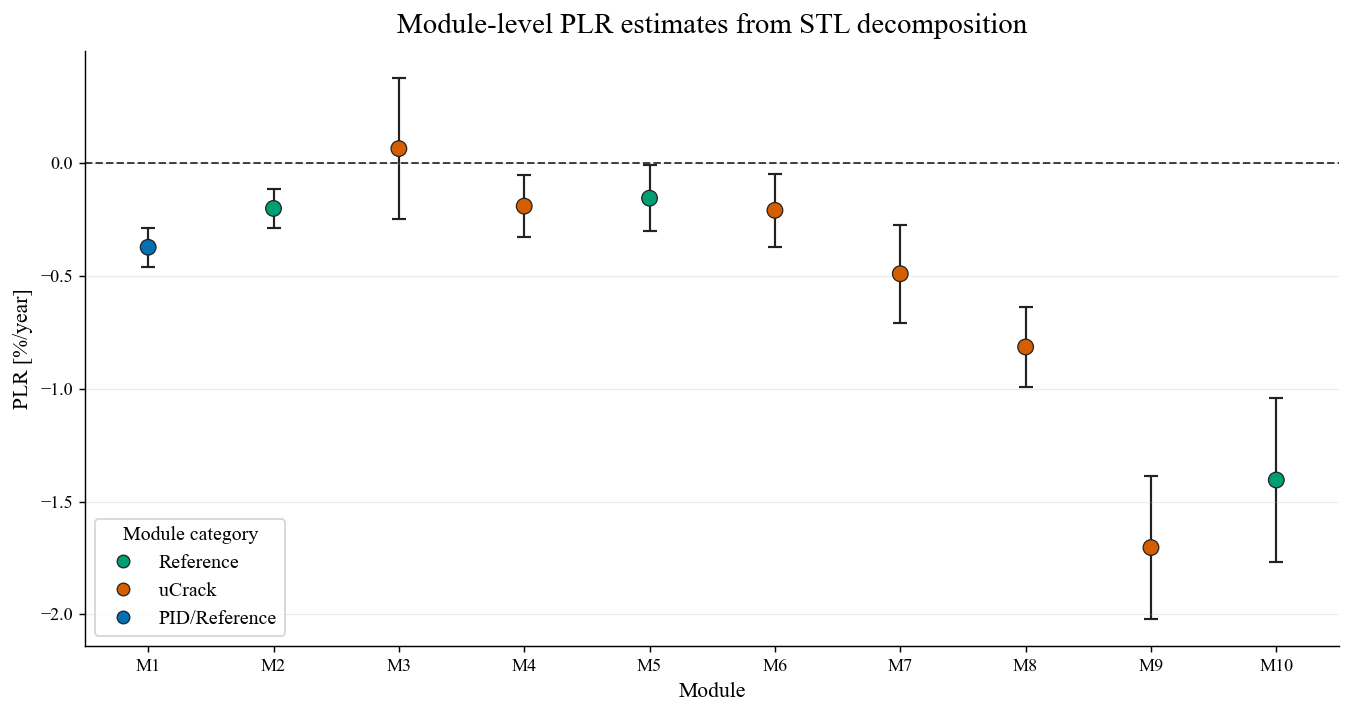

In [15]:
def plot_stl_module_level_plr(
    stl_main_results,
    save_name="stl_module_level_plr_estimates_g200.png",
):
    plot_df = stl_main_results.sort_values("Module_ID").copy()

    x = plot_df["Module_ID"].astype(int).to_numpy()
    y = plot_df["PLR_STL_pct_per_year"].to_numpy()

    yerr_lower = y - plot_df["PLR_STL_ci_low"].to_numpy()
    yerr_upper = plot_df["PLR_STL_ci_high"].to_numpy() - y

    colors = plot_df["Type"].map(TYPE_COLORS).to_list()

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor=BLACK,
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=1,
    )

    ax.scatter(
        x,
        y,
        s=75,
        c=colors,
        edgecolor=BLACK,
        linewidth=0.7,
        zorder=2,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Module-level PLR estimates from STL decomposition",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=module_category_legend_handles(),
        title="Module category",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_stl_module_level_plr(stl_main_results)

## 12. Prepare STL plot data

The decomposition output is merged with module-level STL PLR estimates for plotting.

In [16]:
def get_stl_plot_data(dataset_name=MAIN_DATASET):
    """
    Merge decomposition outputs with module-level STL results.
    """
    decomp = (
        stl_decomposition
        .loc[stl_decomposition["dataset"] == dataset_name]
        .copy()
    )

    results = (
        stl_results
        .loc[stl_results["dataset"] == dataset_name]
        .copy()
    )

    keep_cols = [
        "dataset",
        "Module_ID",
        "Type",
        "PLR_STL_pct_per_year",
        "PLR_STL_ci_low",
        "PLR_STL_ci_high",
        "n_months_imputed",
        "pct_months_imputed",
        "r_squared_trend",
        "r_squared_uncertainty",
        "rmse_trend_plus_residual",
    ]

    merged = decomp.merge(
        results[keep_cols],
        on=["dataset", "Module_ID", "Type"],
        how="left",
    )

    return merged


stl_plot_data_g200 = get_stl_plot_data(MAIN_DATASET)

display(stl_plot_data_g200.head())

,Month_Start,Module_ID,Type,YearMonth,PR_25C,PR_raw,P_MPP,P_MPP_25C,P_STC,FF_measured,...,stl_trend_residual_fit_ci_low,stl_trend_residual_fit_ci_high,PLR_STL_pct_per_year,PLR_STL_ci_low,PLR_STL_ci_high,n_months_imputed,pct_months_imputed,r_squared_trend,r_squared_uncertainty,rmse_trend_plus_residual
0,2017-01-01,1,PID/Reference,2017-01,0.993481,1.042328,93.076267,87.572047,150.0,0.782049,...,0.983608,0.988331,-0.371689,-0.458705,-0.284673,16,27.586207,0.9505,0.559215,0.004472
1,2017-02-01,1,PID/Reference,2017-02,NaN,NaN,NaN,NaN,NaN,NaN,...,0.983364,0.987962,-0.371689,-0.458705,-0.284673,16,27.586207,0.9505,0.559215,0.004472
2,2017-03-01,1,PID/Reference,2017-03,NaN,NaN,NaN,NaN,NaN,NaN,...,0.983143,0.987629,-0.371689,-0.458705,-0.284673,16,27.586207,0.9505,0.559215,0.004472
3,2017-04-01,1,PID/Reference,2017-04,0.965501,0.975570,62.128468,60.534183,150.0,0.781605,...,0.982898,0.987261,-0.371689,-0.458705,-0.284673,16,27.586207,0.9505,0.559215,0.004472
4,2017-05-01,1,PID/Reference,2017-05,0.976131,0.952120,79.599259,81.489125,150.0,0.768630,...,0.982660,0.986906,-0.371689,-0.458705,-0.284673,16,27.586207,0.9505,0.559215,0.004472


## 13. Plot STL trend fits across all modules

This figure shows monthly \(PR_\mathrm{DC,25C}\), the STL trend component, and the regression fit used to estimate the STL PLR. Filled points are observed monthly values, while open points indicate interpolated months used only for STL regularisation.

In [17]:
def stl_annotation_text(module_df):
    row = module_df.iloc[0]

    return (
        f"PLR = {row['PLR_STL_pct_per_year']:.2f}%/year\n"
        f"95% CI [{row['PLR_STL_ci_low']:.2f}, {row['PLR_STL_ci_high']:.2f}]"
    )

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\stl_trend_fits_monthly_prdc25c_g200.png


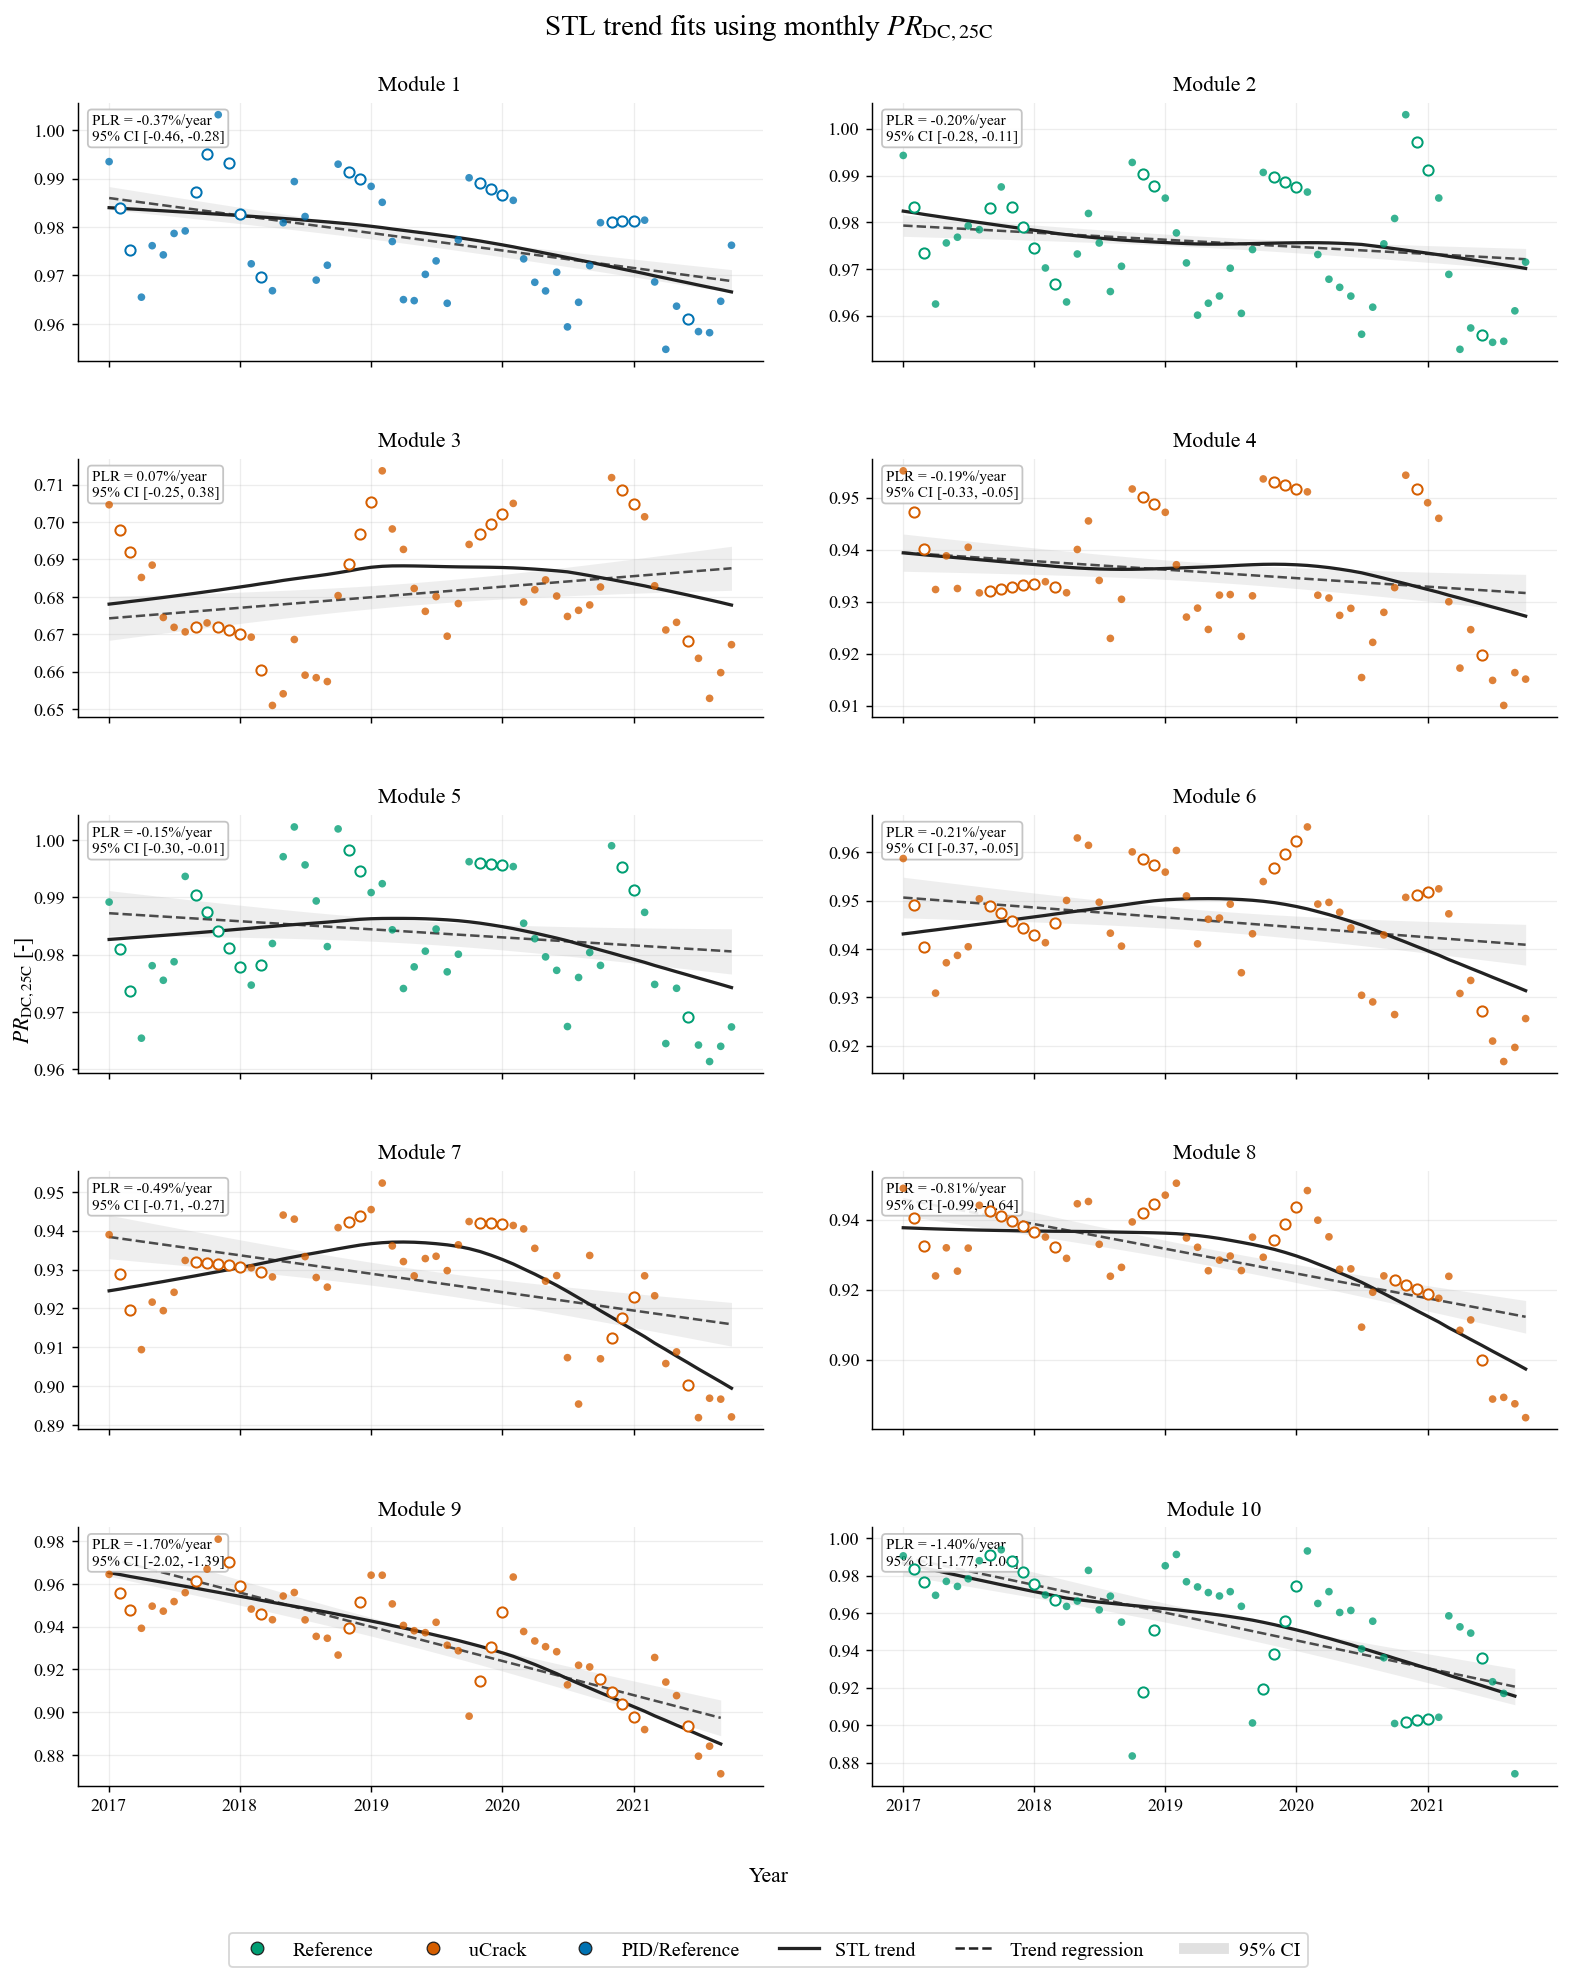

In [18]:
def plot_stl_trend_fits_all_modules(
    stl_plot_data,
    save_name="stl_trend_fits_monthly_prdc25c_g200.png",
):
    panel_df = stl_plot_data.copy()
    module_ids = sorted(panel_df["Module_ID"].unique())

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.5, 15.5),
        sharex=True,
    )

    axes = axes.flatten()

    for ax, module_id in zip(axes, module_ids):
        module_df = (
            panel_df.loc[panel_df["Module_ID"] == module_id]
            .copy()
            .sort_values("Month_Start")
        )

        module_type = module_df["Type"].iloc[0]
        color = TYPE_COLORS[module_type]

        observed_df = module_df.loc[module_df["observed_month"]].copy()
        imputed_df = module_df.loc[module_df["imputed_for_stl"]].copy()

        ax.fill_between(
            module_df["Month_Start"],
            module_df["stl_trend_residual_fit_ci_low"],
            module_df["stl_trend_residual_fit_ci_high"],
            color=GREY,
            alpha=0.25,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            module_df["Month_Start"],
            module_df["stl_trend_residual_regression_fit"],
            color=BLACK,
            linestyle="--",
            linewidth=1.4,
            alpha=0.80,
            zorder=2,
        )

        ax.plot(
            module_df["Month_Start"],
            module_df["stl_trend"],
            color=BLACK,
            linewidth=1.8,
            zorder=3,
        )

        ax.scatter(
            observed_df["Month_Start"],
            observed_df["PR_25C_observed"],
            s=18,
            color=color,
            edgecolors="none",
            alpha=0.78,
            zorder=4,
        )

        ax.scatter(
            imputed_df["Month_Start"],
            imputed_df["stl_input_PR_25C"],
            s=32,
            facecolor="white",
            edgecolor=color,
            linewidth=1.1,
            alpha=1.0,
            zorder=5,
        )

        ax.set_title(f"Module {module_id}", fontsize=SUBTITLE_SIZE, pad=7)
        format_year_axis(ax)

        ax.text(
            0.02,
            0.96,
            stl_annotation_text(module_df),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#BFBFBF",
                alpha=0.90,
            ),
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        r"STL trend fits using monthly $PR_\mathrm{DC,25C}$",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Year", fontsize=AXIS_LABEL_SIZE, y=0.055)
    fig.supylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
        x=0.035,
    )

    fit_handles = [
        Line2D([0], [0], color=BLACK, linewidth=1.8, label="STL trend"),
        Line2D([0], [0], color=BLACK, linestyle="--", linewidth=1.4, label="Trend regression"),
        Line2D([0], [0], color=GREY, linewidth=6, alpha=0.45, label="95% CI"),
    ]

    fig.legend(
        handles=module_category_legend_handles() + fit_handles,
        loc="lower center",
        ncol=6,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
        fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.94,
        bottom=0.105,
        hspace=0.38,
        wspace=0.16,
    )

    save_fig(save_name, fig)
    plt.show()


plot_stl_trend_fits_all_modules(stl_plot_data_g200)

## 14. Plot selected STL decomposition diagnostics

Selected module-level decomposition figures are exported as diagnostics. These show the observed/input series, STL trend, seasonal component, and residual component.

The selected modules can be changed depending on which examples are discussed in the thesis or appendix.

In [19]:
SELECTED_DECOMPOSITION_MODULES = [1, 9]

In [20]:
def plot_stl_decomposition_one_module(
    stl_plot_data,
    module_id,
    dataset_name=MAIN_DATASET,
    save=True,
    show=True,
):
    """
    Plot STL decomposition for one module.
    """
    module_df = (
        stl_plot_data
        .loc[stl_plot_data["Module_ID"] == module_id]
        .copy()
        .sort_values("Month_Start")
    )

    if module_df.empty:
        raise ValueError(f"No STL plot data found for Module {module_id}.")

    module_type = module_df["Type"].iloc[0]
    color = TYPE_COLORS[module_type]

    observed_df = module_df.loc[module_df["observed_month"]].copy()
    imputed_df = module_df.loc[module_df["imputed_for_stl"]].copy()

    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(10.8, 10.2),
        sharex=True,
    )

    axes[0].plot(
        module_df["Month_Start"],
        module_df["stl_input_PR_25C"],
        color=BLACK,
        linewidth=1.1,
        alpha=0.70,
        zorder=1,
    )

    axes[0].scatter(
        observed_df["Month_Start"],
        observed_df["PR_25C_observed"],
        s=28,
        color=color,
        edgecolors="none",
        alpha=0.85,
        label="Observed",
        zorder=2,
    )

    axes[0].scatter(
        imputed_df["Month_Start"],
        imputed_df["stl_input_PR_25C"],
        s=42,
        facecolor="white",
        edgecolor=color,
        linewidth=1.2,
        label="Interpolated",
        zorder=3,
    )

    axes[0].set_ylabel(r"$PR_\mathrm{DC,25C}$ [-]", fontsize=AXIS_LABEL_SIZE)

    axes[1].plot(
        module_df["Month_Start"],
        module_df["stl_trend"],
        color=BLACK,
        linewidth=1.8,
    )
    axes[1].set_ylabel("Trend [-]", fontsize=AXIS_LABEL_SIZE)

    axes[2].plot(
        module_df["Month_Start"],
        module_df["stl_seasonal"],
        color=BLACK,
        linewidth=1.4,
    )
    axes[2].axhline(0, color=GREY, linewidth=1.0)
    axes[2].set_ylabel("Seasonal [-]", fontsize=AXIS_LABEL_SIZE)

    axes[3].plot(
        module_df["Month_Start"],
        module_df["stl_residual"],
        color=BLACK,
        linewidth=1.3,
    )
    axes[3].axhline(0, color=GREY, linewidth=1.0)
    axes[3].set_ylabel("Residual [-]", fontsize=AXIS_LABEL_SIZE)
    axes[3].set_xlabel("Year", fontsize=AXIS_LABEL_SIZE)

    for ax in axes:
        format_year_axis(ax)
        ax.grid(alpha=0.22)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.suptitle(
        f"STL decomposition of Module {module_id} ({module_type})",
        fontsize=TITLE_SIZE,
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if save:
        save_fig(
            f"appendix_stl_decomposition_{dataset_name}_module_{module_id:02d}.png",
            fig,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_stl_decomposition_g200_module_01.png


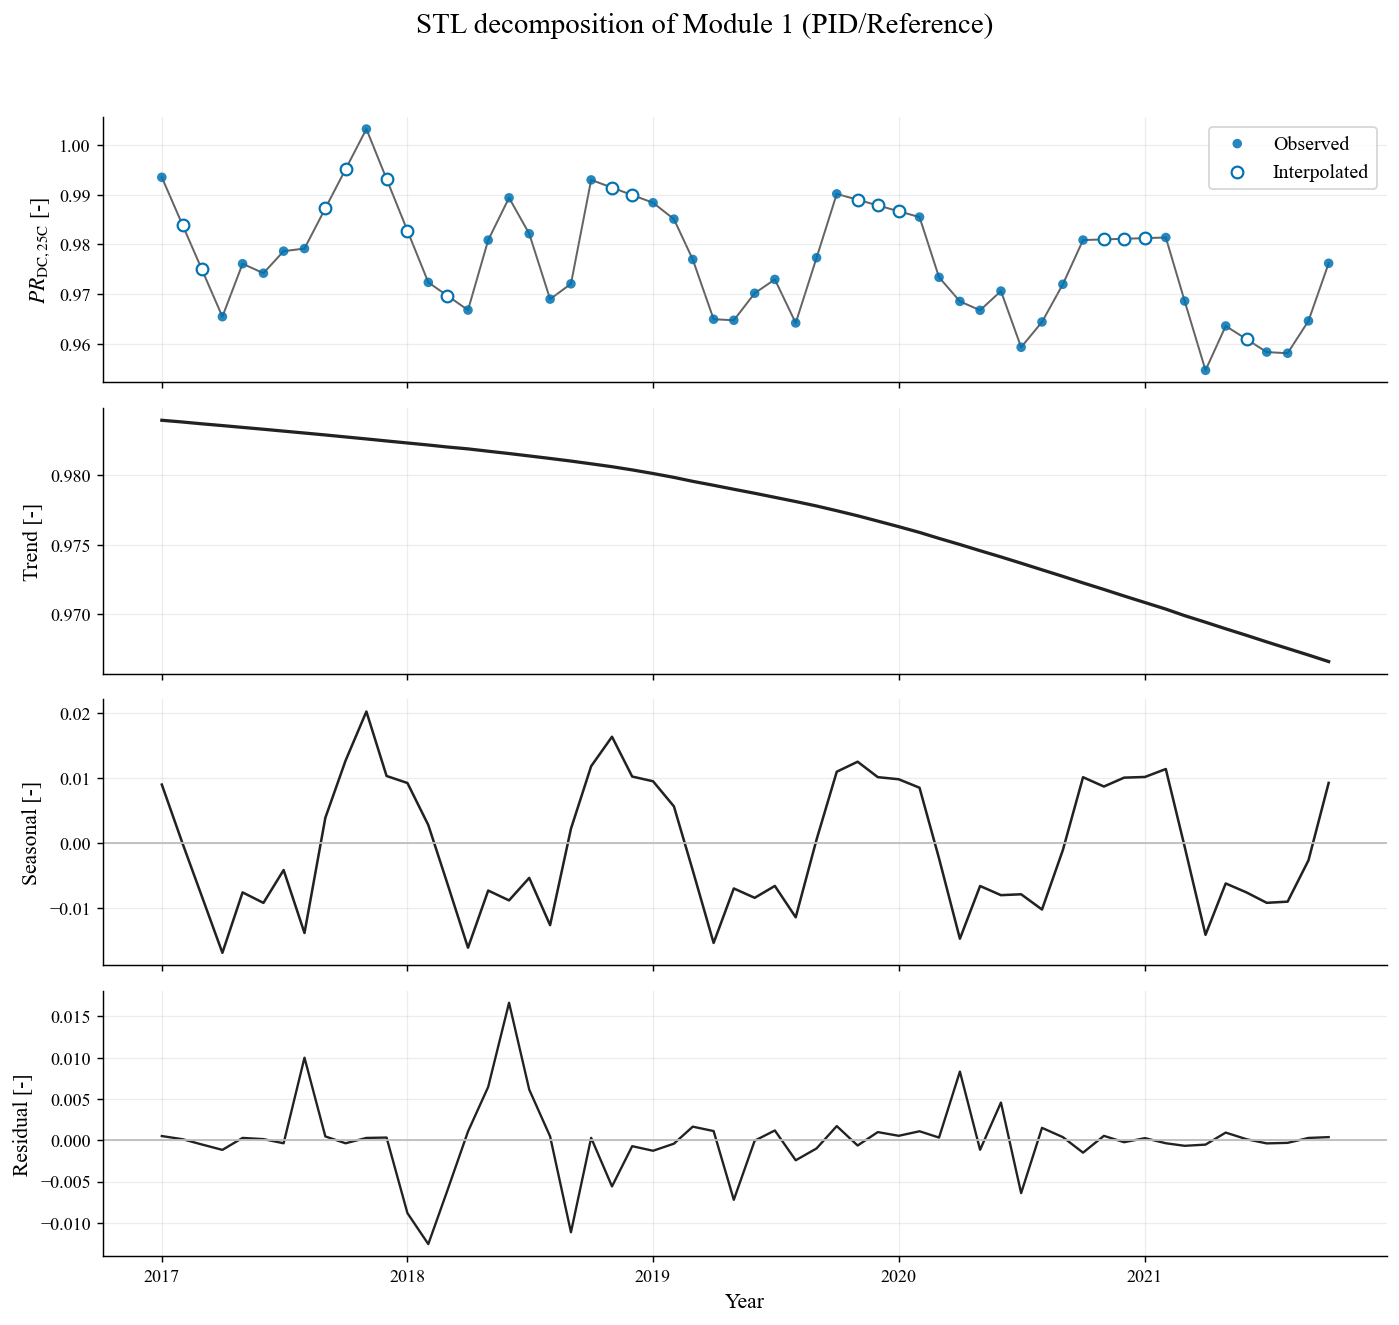

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_stl_decomposition_g200_module_09.png


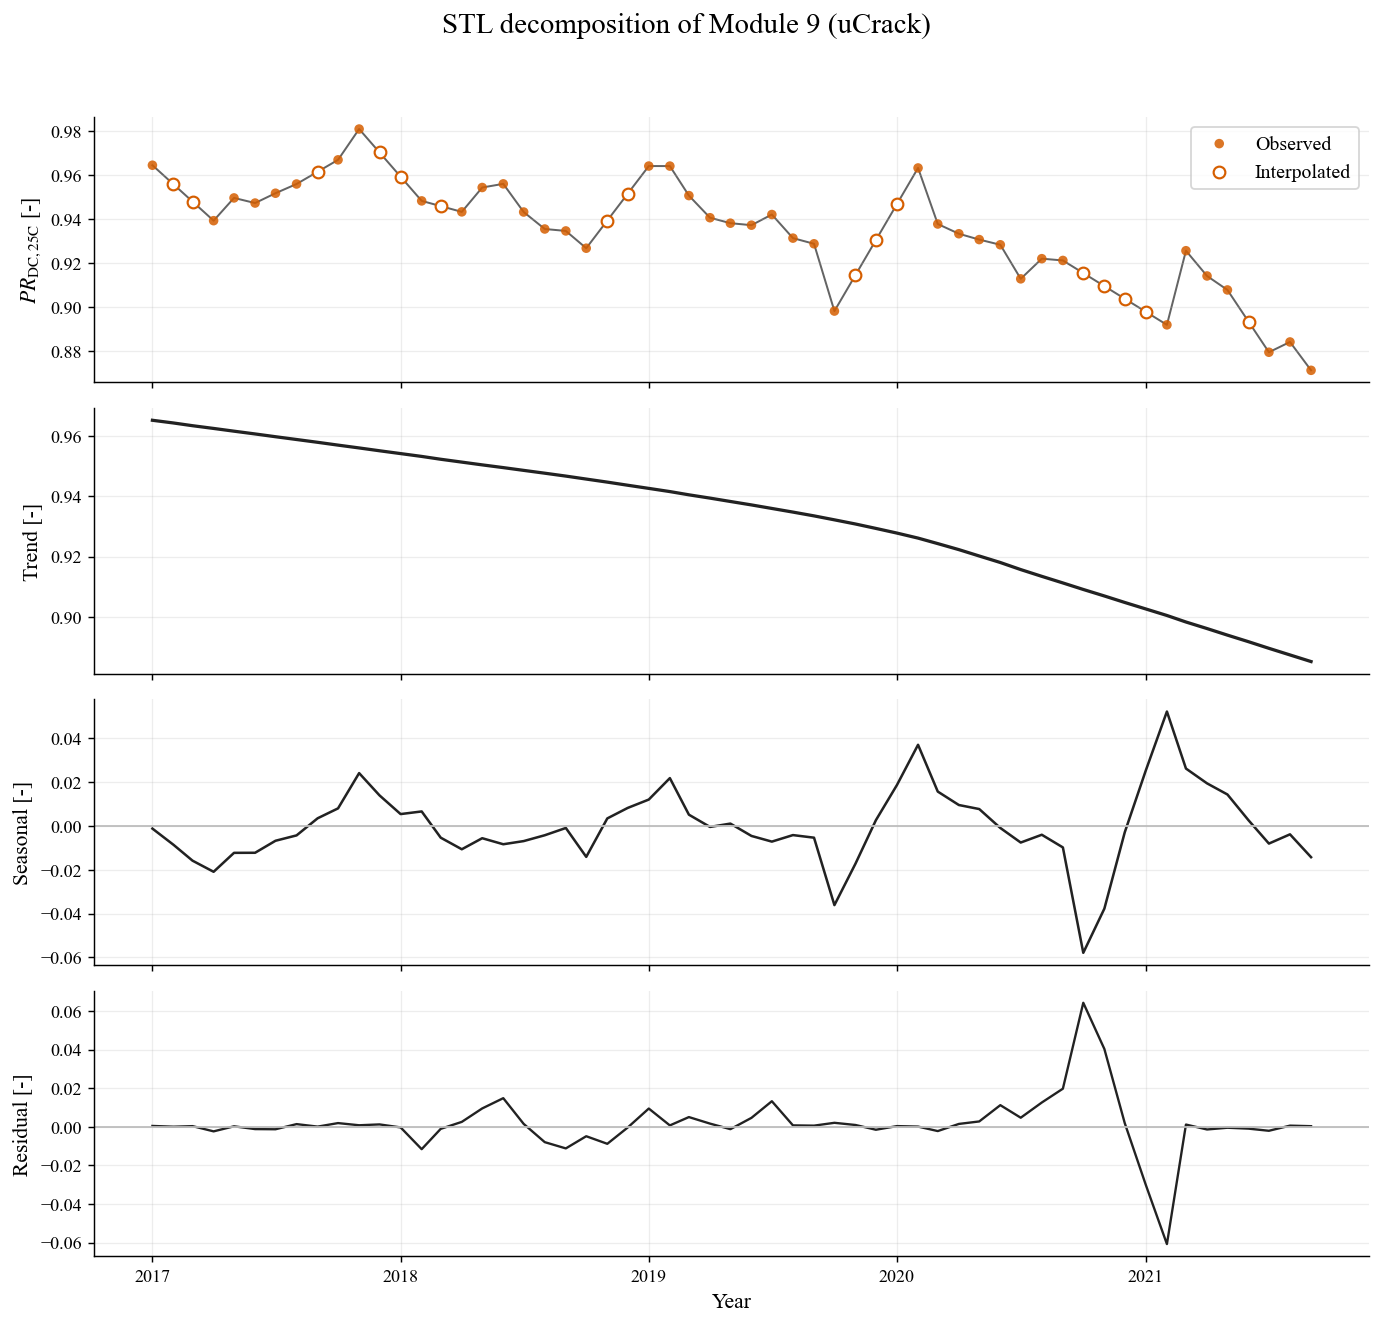

Selected STL decomposition figures exported.


In [22]:
for module_id in SELECTED_DECOMPOSITION_MODULES:
    plot_stl_decomposition_one_module(
        stl_plot_data=stl_plot_data_g200,
        module_id=module_id,
        dataset_name=MAIN_DATASET,
        save=True,
        show=True,
    )

print("Selected STL decomposition figures exported.")

## 15. Irradiance-threshold sensitivity

The g400 dataset is used as a sensitivity check against the main g200 STL results. This table records the shift in STL PLR estimates when the stricter irradiance threshold is used.

In [23]:
g200_results = (
    stl_results
    .loc[stl_results["dataset"] == MAIN_DATASET]
    .copy()
)

g400_results = (
    stl_results
    .loc[stl_results["dataset"] == SENSITIVITY_DATASET]
    .copy()
)

stl_irradiance_sensitivity = g200_results.merge(
    g400_results,
    on=["Module_ID", "Type"],
    suffixes=("_g200", "_g400"),
)

stl_irradiance_sensitivity["PLR_shift_g400_minus_g200"] = (
    stl_irradiance_sensitivity["PLR_STL_pct_per_year_g400"]
    - stl_irradiance_sensitivity["PLR_STL_pct_per_year_g200"]
)

stl_irradiance_sensitivity["abs_PLR_shift_g400_minus_g200"] = (
    stl_irradiance_sensitivity["PLR_shift_g400_minus_g200"].abs()
)

stl_irradiance_sensitivity_display = stl_irradiance_sensitivity[
    [
        "Module_ID",
        "Type",
        "PLR_STL_pct_per_year_g200",
        "PLR_STL_ci_low_g200",
        "PLR_STL_ci_high_g200",
        "PLR_STL_pct_per_year_g400",
        "PLR_STL_ci_low_g400",
        "PLR_STL_ci_high_g400",
        "PLR_shift_g400_minus_g200",
    ]
].copy()

display(stl_irradiance_sensitivity_display)

STL_SENSITIVITY_PATH = FINAL_TABLE_DIR / "stl_irradiance_threshold_sensitivity_g400_minus_g200.csv"

stl_irradiance_sensitivity_display.to_csv(
    STL_SENSITIVITY_PATH,
    index=False,
)

print("Saved STL irradiance sensitivity table:", STL_SENSITIVITY_PATH)

,Module_ID,Type,PLR_STL_pct_per_year_g200,PLR_STL_ci_low_g200,PLR_STL_ci_high_g200,PLR_STL_pct_per_year_g400,PLR_STL_ci_low_g400,PLR_STL_ci_high_g400,PLR_shift_g400_minus_g200
0,1,PID/Reference,-0.371689,-0.458705,-0.284673,-0.168161,-0.275167,-0.061155,0.203528
1,2,Reference,-0.199528,-0.284839,-0.114218,-0.136725,-0.259697,-0.013754,0.062803
2,3,uCrack,0.065959,-0.246740,0.378658,0.341502,0.037994,0.645009,0.275543
3,4,uCrack,-0.189276,-0.327823,-0.050728,-0.223925,-0.348920,-0.098929,-0.034649
4,5,Reference,-0.154026,-0.299295,-0.008757,-0.248653,-0.402093,-0.095213,-0.094627
5,6,uCrack,-0.207915,-0.369104,-0.046726,-0.227390,-0.389009,-0.065771,-0.019475
6,7,uCrack,-0.489180,-0.706909,-0.271451,-0.424680,-0.689987,-0.159372,0.064500
7,8,uCrack,-0.813982,-0.992382,-0.635583,-0.646358,-0.810612,-0.482104,0.167624
8,9,uCrack,-1.703723,-2.021128,-1.386317,-1.325074,-1.508184,-1.141964,0.378649
9,10,Reference,-1.404105,-1.765912,-1.042298,-0.830234,-0.982540,-0.677928,0.573871


Saved STL irradiance sensitivity table: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_irradiance_threshold_sensitivity_g400_minus_g200.csv


## 16. Prepare ensemble-ready STL results

The STL results are reformatted for the ensemble comparison notebook.

In [24]:
stl_for_ensemble = stl_results.copy()

stl_for_ensemble["method"] = "STL"
stl_for_ensemble["metric"] = "PR_DC,25C"
stl_for_ensemble["aggregation"] = "Monthly"
stl_for_ensemble["is_main_dataset"] = stl_for_ensemble["dataset"].eq(MAIN_DATASET)

stl_for_ensemble = stl_for_ensemble.rename(
    columns={
        "PLR_STL_pct_per_year": "PLR_pct_per_year",
        "PLR_STL_ci_low": "PLR_ci_low",
        "PLR_STL_ci_high": "PLR_ci_high",
    }
)

ensemble_cols = [
    "method",
    "dataset",
    "dataset_label",
    "is_main_dataset",
    "metric",
    "aggregation",
    "Module_ID",
    "Type",
    "n_months_regular",
    "n_months_observed",
    "n_months_imputed",
    "pct_months_imputed",
    "first_month",
    "last_month",
    "PLR_pct_per_year",
    "PLR_ci_low",
    "PLR_ci_high",
    "slope_trend_per_year",
    "slope_uncertainty_se",
    "p_value_slope_uncertainty",
    "r_squared_trend",
    "r_squared_uncertainty",
    "rmse_trend_plus_residual",
    "rmse_stl_residual",
    "stl_period",
    "stl_seasonal",
    "stl_trend_window",
    "stl_robust",
]

stl_for_ensemble = (
    stl_for_ensemble[ensemble_cols]
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

display(stl_for_ensemble)

,method,dataset,dataset_label,is_main_dataset,metric,aggregation,Module_ID,Type,n_months_regular,n_months_observed,...,slope_uncertainty_se,p_value_slope_uncertainty,r_squared_trend,r_squared_uncertainty,rmse_trend_plus_residual,rmse_stl_residual,stl_period,stl_seasonal,stl_trend_window,stl_robust
0,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,1,PID/Reference,58,42,...,0.000428,1.530224e-11,0.950500,0.559215,0.004472,0.004355,12,13,31,True
1,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,2,Reference,58,43,...,0.000418,6.094889e-04,0.898872,0.190721,0.004360,0.004204,12,13,31,True
2,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,3,uCrack,58,42,...,0.001066,1.064932e-02,0.034138,0.110873,0.011132,0.011512,12,13,31,True
3,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,4,uCrack,58,43,...,0.000650,1.472618e-02,0.698988,0.101632,0.006786,0.006474,12,13,31,True
4,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,5,Reference,58,42,...,0.000715,5.462027e-02,0.408417,0.064380,0.007469,0.006702,12,13,31,True
5,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,6,uCrack,58,42,...,0.000764,9.294702e-03,0.287948,0.114747,0.007978,0.006239,12,13,31,True
6,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,7,uCrack,58,41,...,0.001019,2.083540e-05,0.380319,0.278367,0.010635,0.005889,12,13,31,True
7,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,8,uCrack,58,40,...,0.000842,1.840696e-11,0.780949,0.556336,0.008796,0.006051,12,13,31,True
8,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,9,uCrack,57,41,...,0.001539,1.425700e-14,0.963288,0.662189,0.015649,0.014603,12,13,31,True
9,STL,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,10,Reference,57,40,...,0.001783,2.702249e-11,0.969468,0.556830,0.018132,0.017524,12,13,31,True


In [25]:
STL_ENSEMBLE_CSV_PATH = FINAL_TABLE_DIR / "stl_for_ensemble.csv"
STL_ENSEMBLE_PARQUET_PATH = STL_OUTPUT_DIR / "stl_for_ensemble.parquet"

stl_for_ensemble.to_csv(STL_ENSEMBLE_CSV_PATH, index=False)
stl_for_ensemble.to_parquet(STL_ENSEMBLE_PARQUET_PATH, index=False)

print("Saved ensemble-ready STL CSV:", STL_ENSEMBLE_CSV_PATH)
print("Saved ensemble-ready STL parquet:", STL_ENSEMBLE_PARQUET_PATH)

Saved ensemble-ready STL CSV: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\stl_for_ensemble.csv
Saved ensemble-ready STL parquet: C:\Users\amina\Thesis\Final Pipeline\data_processed\stl_outputs\stl_for_ensemble.parquet
